In [4]:
#ex 1
import tensorflow as tf
import numpy as np

X = np.array([0, 1, 2, 3, 4], dtype=float)

# Y = 3X + 2
Y = np.array([2, 5, 8, 11, 14], dtype=float)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=1, input_shape=[1])
])
model.compile(
    optimizer='sgd',

    loss='mean_squared_error'
)

model.fit(X, Y, epochs=500, verbose=0)

# Predictioes
prediction1 = model.predict(np.array([5]))
prediction2 = model.predict(np.array([3.3]))

print("Prediction for X = 5:")
print(prediction1)
print("\nPrediction for X =3.3")
print(prediction2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Prediction for X = 5:
[[17.01414]]

Prediction for X =3.3
[[11.902954]]


In [5]:
# ex2
import tensorflow as tf
import numpy as np
X = np.array([0, 1, 2, 3, 4], dtype=float)
Y = np.array([2, 5, 8, 11, 14], dtype=float)

model = tf.keras.Sequential([

    tf.keras.layers.Dense(10, activation='relu', input_shape=[1]),
    tf.keras.layers.Dense(10, activation='relu'),

    tf.keras.layers.Dense(1)
])

model.compile(

    optimizer='adam',

    loss='mean_squared_error'
)

model.fit(X, Y, epochs=1000, verbose=0)

prediction1 = model.predict(np.array([5]))
prediction2 = model.predict(np.array([3.3]))

# Print predictions
print("Prediction for X = 5:")
print(prediction1)

print("\nPrediction for X = 3.3:")
print(prediction2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Prediction for X = 5:
[[16.811483]]

Prediction for X = 3.3:
[[11.853182]]


In [8]:
# ex3
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

data = {
    'text': [
        'Win money now',
        'Congratulations you won a prize',
        'Call me later',
        'Meeting at 5 pm',
        'Free vacation offer',
        'How are you today',
        'Claim your reward now',
        'Lets study together'
    ],

    # 1 = Spam    0 = No Spam
    'label': [1,1,0,0,1,0,1,0]
}

df = pd.DataFrame(data)

print(df)

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['text']).toarray()
Y = df['label']

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(X.shape[1],)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train, Y_train, epochs=100, verbose=0)
loss, accuracy = model.evaluate(X_test, Y_test)

print("\nModel Accuracy:")
print(accuracy)

mail = ["Free money prize"]
vectormail = vectorizer.transform(mail).toarray()

prediction = model.predict(vectormail)

print("\nPrediction for:", mail[0])

if prediction[0][0] > 0.5:
    print("Spam")
else:
    print("Not Spam")

                              text  label
0                    Win money now      1
1  Congratulations you won a prize      1
2                    Call me later      0
3                  Meeting at 5 pm      0
4              Free vacation offer      1
5                How are you today      0
6            Claim your reward now      1
7              Lets study together      0


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.0000e+00 - loss: 0.7729

Model Accuracy:
0.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step

Prediction for: how can I help you
Spam


In [9]:
# ex4
import pandas as pd

data = {
    "Student Name": ["Thaby", "Nath", "Julian", "Rondo"],
    "Student Age": [21, 22, 20, 23],
    "No. of Lab completed": [10, 8, 9, 7],
    "Average score": [95, 88, 91, 85]
}

df = pd.DataFrame(data)

df.to_excel("students.xlsx", index=False)

students = pd.read_excel("students.xlsx")

def print_student(row):

    print(
        "Name:", row["Student Name"],
        "| Age:", row["Student Age"],
        "| Labs:", row["No. of Lab completed"],
        "| Average:", row["Average score"]
    )

students.apply(print_student, axis=1)

Name: Thaby | Age: 21 | Labs: 10 | Average: 95
Name: Carlos | Age: 22 | Labs: 8 | Average: 88
Name: Maria | Age: 20 | Labs: 9 | Average: 91
Name: Ana | Age: 23 | Labs: 7 | Average: 85


,0
0,None
1,None
2,None
3,None


Dataset Original:

    Costo promedio de compra  Promedio de compras con tarjeta
0                        750                                3
1                       1245                                1
2                        230                                4
3                        533                                3
4                        490                                2
5                       1000                                1
6                        190                                0
7                        900                                3
8                        600                                2
9                         50                                1
10                      1100                                0
11                       930                                4
12                       450                                3
13                       330                                2
14                       750                       

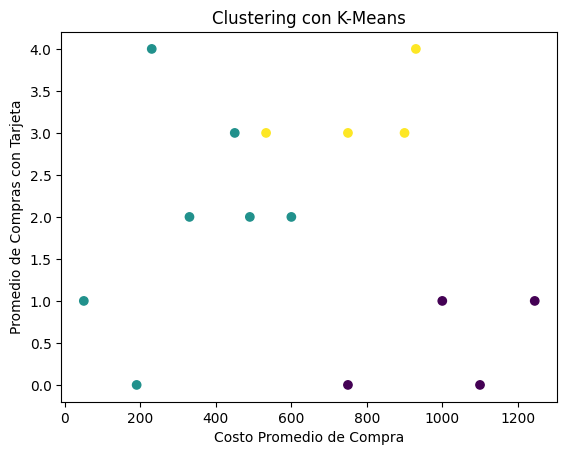

In [28]:
#ex5
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

data = {
    'promedio de compra': [750, 1245, 230, 533, 490, 1000, 190, 900, 600, 50, 1100, 930, 450, 330, 750],
    'Promedio de compras con tarjeta': [3, 1, 4, 3, 2, 1, 0, 3, 2, 1, 0, 4, 3, 2, 0]
}

df = pd.DataFrame(data)

print("Dataset Original:\n")
print(df)

scaler = StandardScaler()

datos_escalados = scaler.fit_transform(df)

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

kmeans.fit(datos_escalados)

df['Cluster'] = kmeans.labels_

print("\nDataset con Clusters:\n")
print(df)

plt.scatter(
    df['promedio de compra'],
    df['Promedio de compras con tarjeta'],
    c=df['Cluster']
)

plt.xlabel('promedio de Compra')
plt.ylabel('Promedio de Compras con tarjeta')
plt.title('Clustering con K-Means')

plt.show()

Original Dataset:

    X   Y
0   1   2
1   2   1
2   3   2
3   4   4
4   5   5
5   6   4
6   7   7
7   8   8
8   9   9
9  10  10


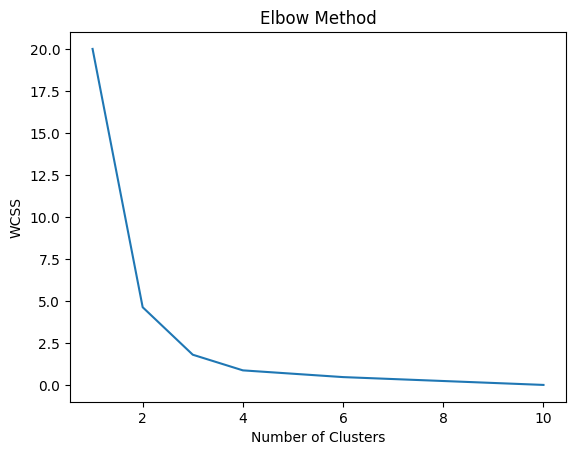


Dataset with clusters:

    X   Y  Cluster
0   1   2        2
1   2   1        2
2   3   2        2
3   4   4        0
4   5   5        0
5   6   4        0
6   7   7        1
7   8   8        1
8   9   9        1
9  10  10        1


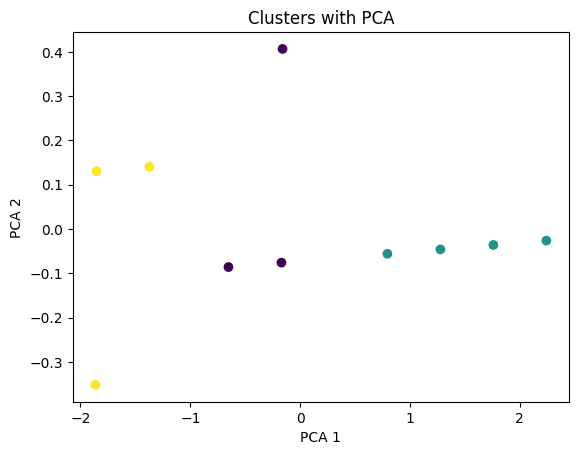

In [ ]:
# ex6
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

data = {
    'X': [1,2,3,4,5,6,7,8,9,10],
    'Y': [2,1,2,4,5,4,7,8,9,10]
}
df = pd.DataFrame(data)

print("Original Dataset:\n")
print(df)

df = df.dropna()

dataset = df[['X', 'Y']]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(dataset)

wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

kmeans = KMeans(n_clusters=3,random_state=42)

clusters = kmeans.fit_predict(scaled_data)

df['Cluster'] = clusters

print("\nDataset with clusters:\n")
print(df)

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.scatter(pca_data[:,0], pca_data[:,1],c=clusters)

plt.title('Clusters with PCA')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()=